Execution steps:
1. Create a 3-regular graph G
2. Convert to QAOA circuit
3. Convert QAOA circuit to line graph representation LG
4. Find the best order with respect to contraction width with rgreedy algorithm
5. Plot of computational cost or contraction width
5. Contract LG with step-dependent slicing:
    1. Steps s before the peak
    2. Remove r vertices with the biggest number of neighbors
    3. Re-run ordering algorithm to find new contraction width
    4. Find optimal s
6. Graphs about computational cost or contraction width and benchmarking

In [1]:
from graph import *
from plots import *
from ordering import *
from conversion import *
import networkx as nx

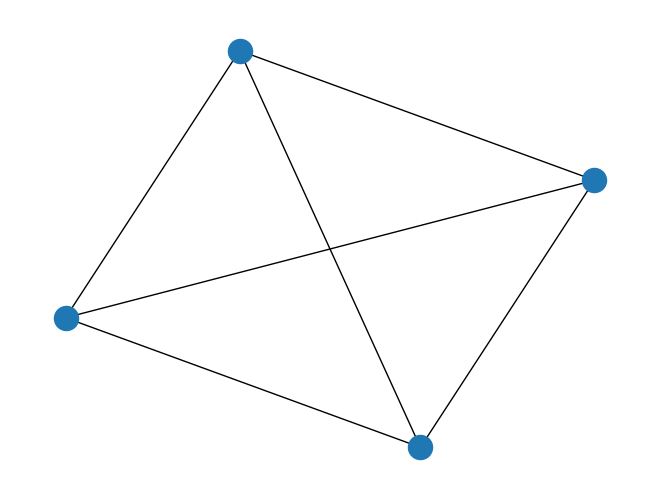

In [2]:
G = createGraph(4)
nx.draw(G)

Number of gates: 22


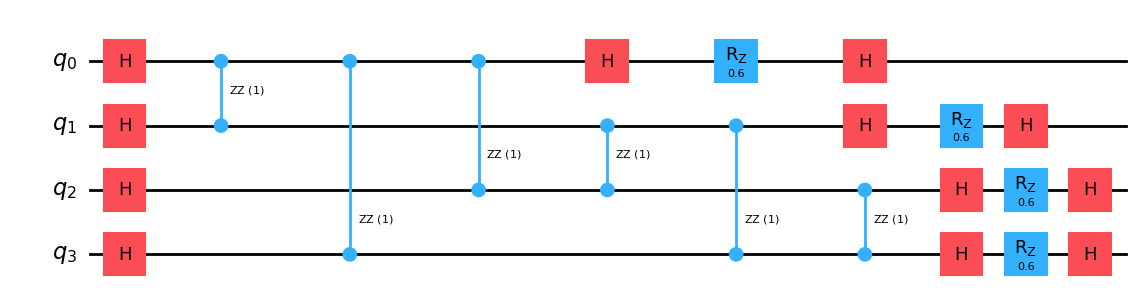

In [3]:
circuit = createCircuit(G)
print(f"Number of gates: {len(circuit.data)}")
circuit.draw('mpl')

Number of nodes: 32
Number of edges: 52


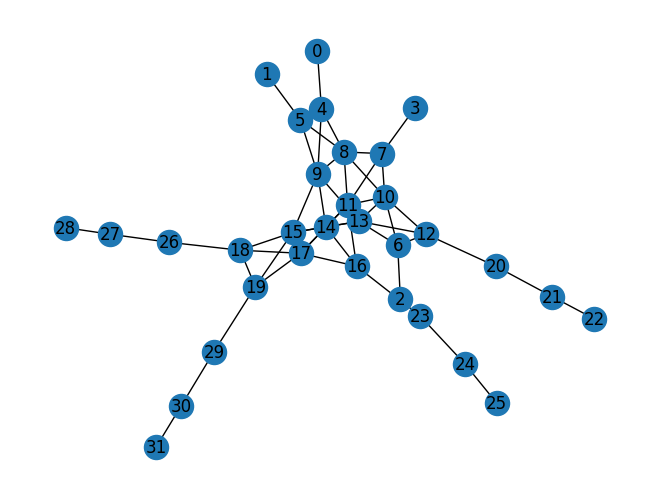

In [4]:
LG = convertToLineGraph(circuit)
nx.draw(LG, with_labels=True)
print(f"Number of nodes: {LG.number_of_nodes()}")
print(f"Number of edges: {LG.number_of_edges()}")

In [5]:
order, c_width, widths = rgreedy(LG, 0.05, 50)
newOrder, newCWidth, newWidths, optimalS, toSlice = findOptimalS(LG, widths, order)

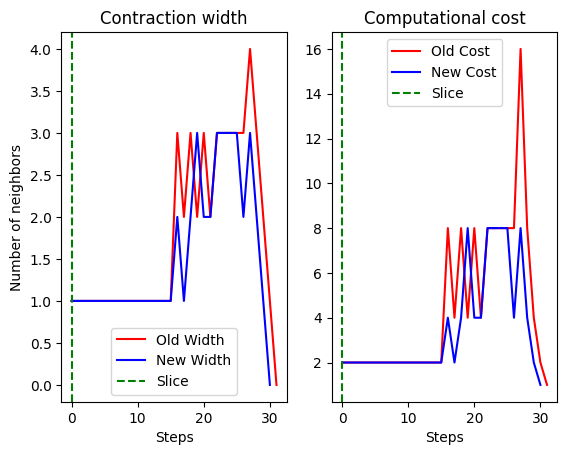

In [6]:
plotComparison(widths, newWidths, optimalS)

In [7]:

print(f"Contraction width was {c_width} now it's {newCWidth} with optimal step S = {optimalS}")
print(f"Computational cost was {math.exp2(c_width)}, now it's {math.exp2(newCWidth)} which is a reduction of {math.exp2(c_width)/math.exp2(newCWidth)}")


Contraction width was 4 now it's 3 with optimal step S = 0
Computational cost was 16.0, now it's 8.0 which is a reduction of 2.0
